In [1]:
import pytest
import networkx as nx
from cyberbattle.simulation.actions_test import ENV, ENV_IDENTIFIERS, NODES
import cyberbattle.simulation.model as model
import cyberbattle.simulation.actions as actions
import cyberbattle.simulation.vulnerability_graph as vg
import plotly.offline as plo
import matplotlib.pyplot as plt  # type:ignore

from typing import (
    Iterator,
    List,
    NamedTuple,
    Optional,
    Set,
    Tuple,
    Dict,
    TypedDict,
    cast,
)
plo.init_notebook_mode(connected=True) # type: ignore
%matplotlib inline

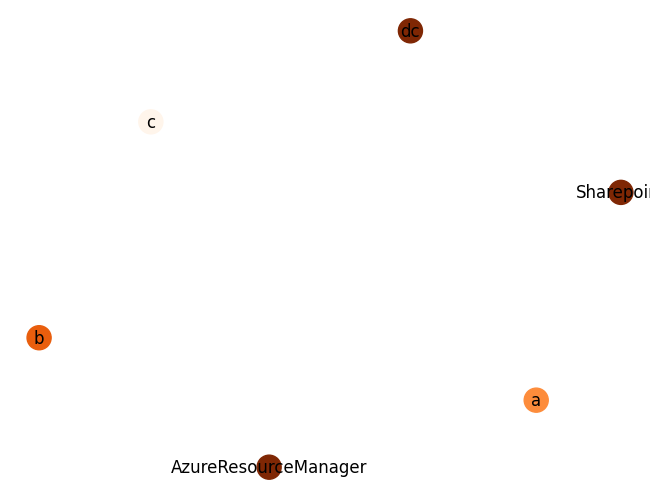

In [2]:
ENV.plot_environment_graph()

True
[[ 0 45 45 45 45  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0 45]
 [ 0  0  0  0  0  0]]


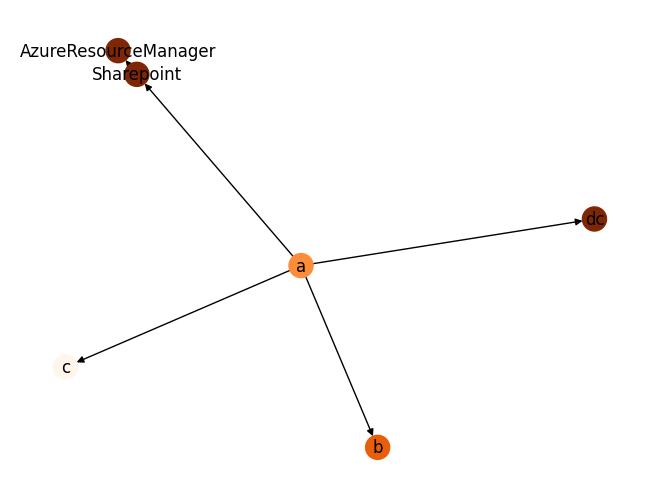

In [3]:
attacker = actions.AgentActions(ENV)
defender = actions.DefenderAgentActions(ENV, attacker, 10)
# attacker.print_all_attacks()
# print(attacker.list_vulnerabilities_in_target("a"))

# def build_edges(nodes: List[actions.DiscoveredNodeInfo]):
#     for n in [x for x in nodes if x["status"] == "owned"]:
#         try:
#             local_attacks = attacker.list_local_attacks(n["id"])
#             for attack in local_attacks:
#                 if attacker.__process_outcome(model.VulnerabilityType.LOCAL, attack, n["id"],defender._environment.get_node(n["id"]), False, 0, True):
#                     attacker.__annotate_edge()
#         except:
# build_edges()

for i, x in defender.get_vulnerable_nodes():
    defender.identify_vulnerable_neighbour(i,x)
# print(nx.adjacency_matrix(defender.get_vulnerability_graph()))
def plot_environment_graph(network) -> None:
        """Plot the full environment graph"""
        nx.draw(network, with_labels=True, node_color=[n["data"].value for i, n in network.nodes.items()], cmap=plt.cm.Oranges)  # type:ignore
plot_environment_graph(defender.get_vulnerability_graph())
print(defender.get_vulnerability_graph().has_edge("Sharepoint", "AzureResourceManager"))
print(nx.to_numpy_array(defender.get_vulnerability_graph(), None, dtype=int))


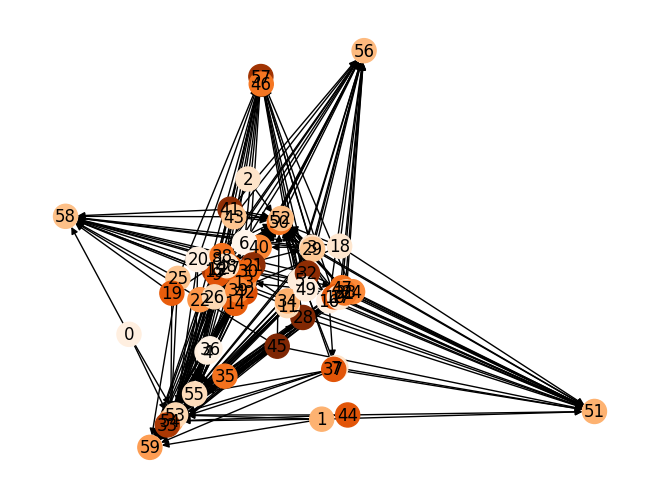

In [4]:
from cyberbattle.simulation.generate_network import new_environment
random_env = new_environment(10)
attacker = actions.AgentActions(random_env)
defender = actions.DefenderAgentActions(random_env, attacker, 10)
for k, info in defender.get_vulnerable_nodes():
    defender.identify_vulnerable_neighbour(k, info)
plot_environment_graph(defender.get_vulnerability_graph())
adj_matrix = nx.to_numpy_array(defender.get_vulnerability_graph(), None, dtype=int)


with open('adjacency_matrix.txt', 'w') as f:
    for row in adj_matrix:
        f.write(' '.join(map(str, row)) + '\n')